In [0]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

spark = SparkSession.builder.appName("FraudPipeline").getOrCreate()


bronze_path = "/Volumes/workspace/default/bigdata/creditcard.csv"

df = spark.read.csv(bronze_path, header=True, inferSchema=True)


df = df.dropDuplicates()
df = df.na.drop("any")


from pyspark.ml.feature import VectorAssembler, StandardScaler

scale_assembler = VectorAssembler(
    inputCols=["Time", "Amount"],
    outputCol="to_scale"
)
df_scaled = scale_assembler.transform(df)

scaler = StandardScaler(inputCol="to_scale", outputCol="scaled_features",
                        withMean=True, withStd=True)
scaler_model = scaler.fit(df_scaled)
df_scaled = scaler_model.transform(df_scaled)


pca_features = [f"V{i}" for i in range(1, 29)]

assembler = VectorAssembler(
    inputCols=pca_features + ["scaled_features"],
    outputCol="features"
)
final_df = assembler.transform(df_scaled)


fraud = df.filter(col("Class") == 1).count()
normal = df.filter(col("Class") == 0).count()

balancing_ratio = normal / (fraud + normal)

final_df = final_df.withColumn(
    "classWeightCol",
    when(col("Class") == 1, balancing_ratio).otherwise(1 - balancing_ratio)
)


silver_path = "/Volumes/workspace/default/bigdata/silver_fraud/"

final_df.write.format("delta").mode("overwrite").save(silver_path)

print("SILVER table saved!")


SILVER table saved!


In [0]:

train_df, test_df = final_df.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

lr = LogisticRegression(
    featuresCol="features",
    labelCol="Class",
    weightCol="classWeightCol",
    maxIter=20
)

lr_model = lr.fit(train_df)
lr_pred = lr_model.transform(test_df)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="Class",
    numTrees=50,
    maxDepth=8
)

rf_model = rf.fit(train_df)
rf_pred = rf_model.transform(test_df)

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="Class",
    maxIter=50,
    maxDepth=5
)

gbt_model = gbt.fit(train_df)
gbt_pred = gbt_model.transform(test_df)

pr_evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    rawPredictionCol="probability",
    metricName="areaUnderPR"
)

roc_evaluator = BinaryClassificationEvaluator(
    labelCol="Class",
    rawPredictionCol="probability",
    metricName="areaUnderROC"
)

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "GBT": gbt_pred
}



Training rows: 227183
Testing rows: 56543


In [0]:
from pyspark.sql import functions as F

def confusion_matrix(pred_df):
    return pred_df.groupBy("Class", "prediction").count().orderBy("Class", "prediction")

print("Logistic Regression Confusion:")
display(confusion_matrix(lr_pred))

print("Random Forest Confusion:")
display(confusion_matrix(rf_pred))

print("GBT Confusion:")
display(confusion_matrix(gbt_pred))


Logistic Regression Confusion:


Class,prediction,count
0,0.0,55313
0,1.0,1135
1,0.0,12
1,1.0,83


Random Forest Confusion:


Class,prediction,count
0,0.0,56442
0,1.0,6
1,0.0,31
1,1.0,64


GBT Confusion:


Class,prediction,count
0,0.0,56443
0,1.0,5
1,0.0,31
1,1.0,64


In [0]:
from pyspark.sql import functions as F

def confusion_matrix(df, model_name):
    cm = df.groupBy("Class", "prediction").count().orderBy("Class", "prediction")
    display(cm)

lr_train_pred = lr_model.transform(train_df)
rf_train_pred = rf_model.transform(train_df)
gbt_train_pred = gbt_model.transform(train_df)

confusion_matrix(lr_train_pred, "Logistic Regression")
confusion_matrix(rf_train_pred, "Random Forest")
confusion_matrix(gbt_train_pred, "GBT Classifier")


===== Confusion Matrix: Logistic Regression (TRAIN DATA) =====


Class,prediction,count
0,0.0,221917
0,1.0,4888
1,0.0,31
1,1.0,347



===== Confusion Matrix: Random Forest (TRAIN DATA) =====


Class,prediction,count
0,0.0,226794
0,1.0,11
1,0.0,65
1,1.0,313



===== Confusion Matrix: GBT Classifier (TRAIN DATA) =====


Class,prediction,count
0,0.0,226800
0,1.0,5
1,0.0,65
1,1.0,313


In [0]:
from pyspark.sql.functions import col
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import pandas as pd


def get_metrics(pred_df):
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="Class", predictionCol="prediction", metricName="accuracy"
    )
    evaluator_precision = MulticlassClassificationEvaluator(
        labelCol="Class", predictionCol="prediction", metricName="weightedPrecision"
    )
    evaluator_recall = MulticlassClassificationEvaluator(
        labelCol="Class", predictionCol="prediction", metricName="weightedRecall"
    )
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="Class", predictionCol="prediction", metricName="f1"
    )

    return {
        "Accuracy": evaluator_acc.evaluate(pred_df),
        "Precision": evaluator_precision.evaluate(pred_df),
        "Recall": evaluator_recall.evaluate(pred_df),
        "F1 Score": evaluator_f1.evaluate(pred_df)
    }


results = {
    "Model": [],
    "Dataset": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1 Score": []
}

models_train = {
    "Logistic Regression": lr_model.transform(train_df),
    "Random Forest": rf_model.transform(train_df),
    "GBT": gbt_model.transform(train_df)
}

models_test = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "GBT": gbt_pred
}


for name, preds in models_train.items():
    m = get_metrics(preds)
    results["Model"].append(name)
    results["Dataset"].append("Train")
    results["Accuracy"].append(m["Accuracy"])
    results["Precision"].append(m["Precision"])
    results["Recall"].append(m["Recall"])
    results["F1 Score"].append(m["F1 Score"])

for name, preds in models_test.items():
    m = get_metrics(preds)
    results["Model"].append(name)
    results["Dataset"].append("Test")
    results["Accuracy"].append(m["Accuracy"])
    results["Precision"].append(m["Precision"])
    results["Recall"].append(m["Recall"])
    results["F1 Score"].append(m["F1 Score"])


metrics_df = pd.DataFrame(results)
metrics_df


,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Train,0.978348,0.998307,0.978348,0.987599
1,Random Forest,Train,0.999665,0.999657,0.999665,0.999653
2,GBT,Train,0.999692,0.999688,0.999692,0.999679
3,Logistic Regression,Test,0.979715,0.998218,0.979715,0.988288
4,Random Forest,Test,0.999346,0.999308,0.999346,0.999296
5,GBT,Test,0.999363,0.999330,0.999363,0.999313


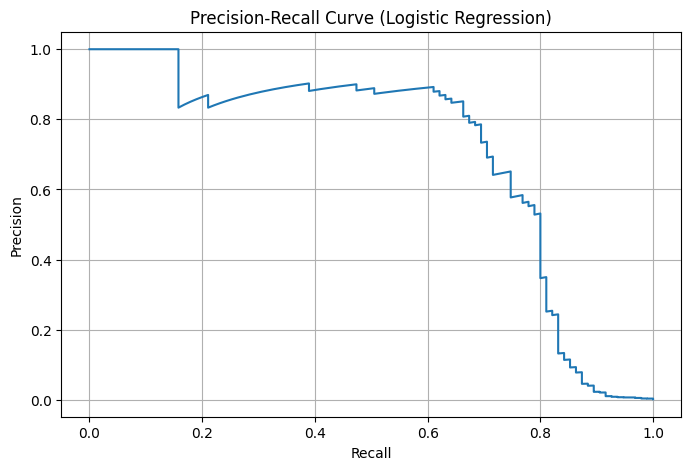

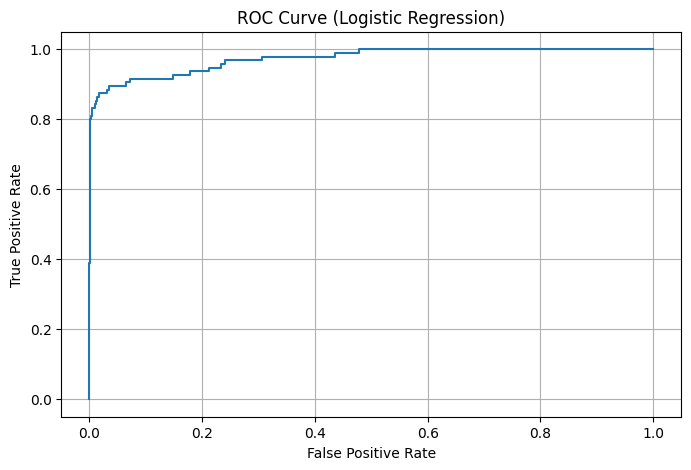

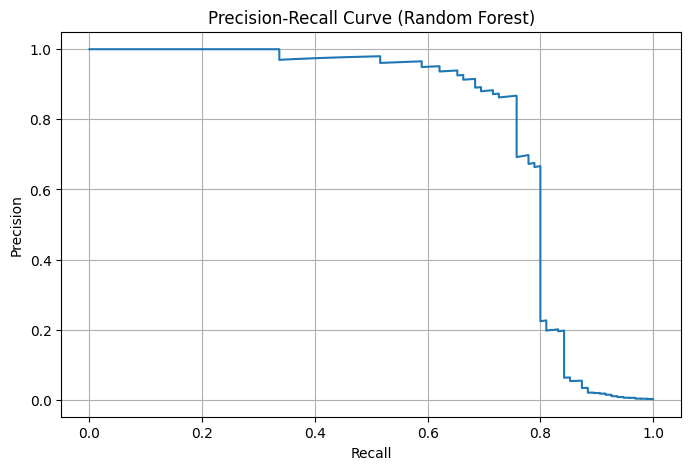

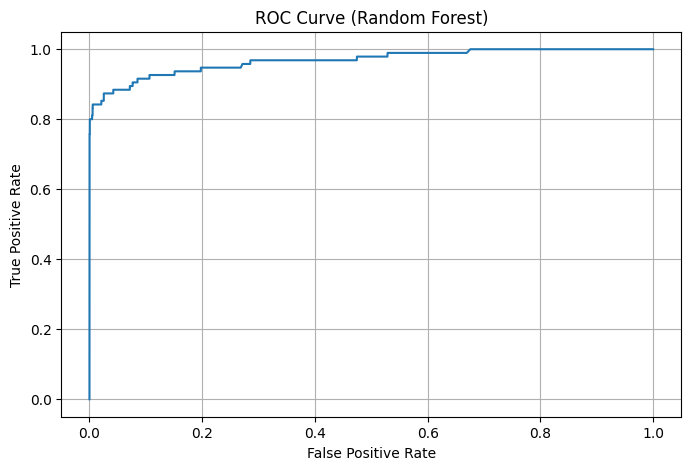

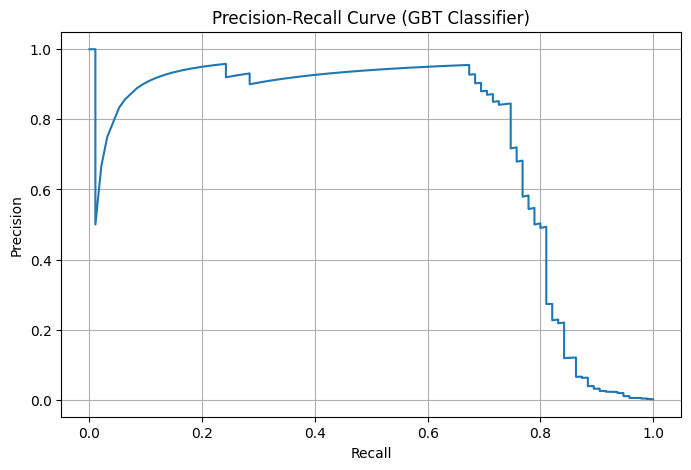

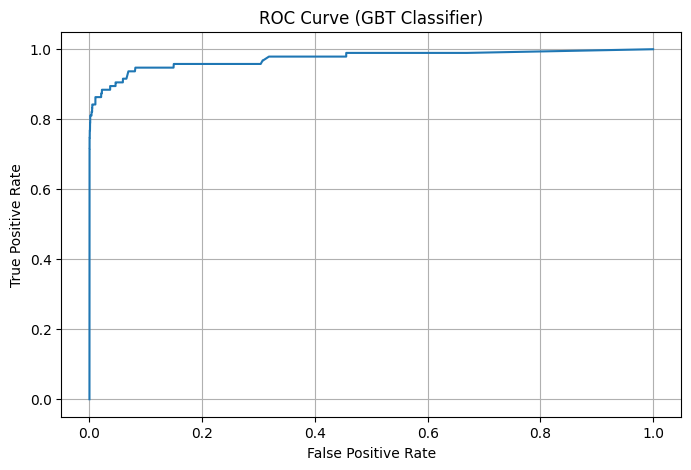

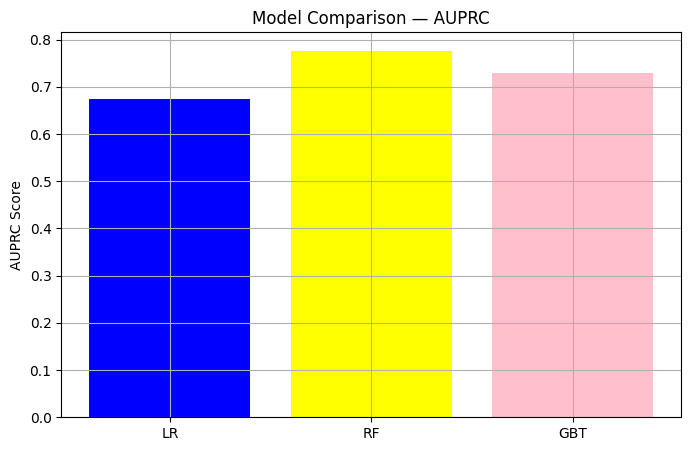

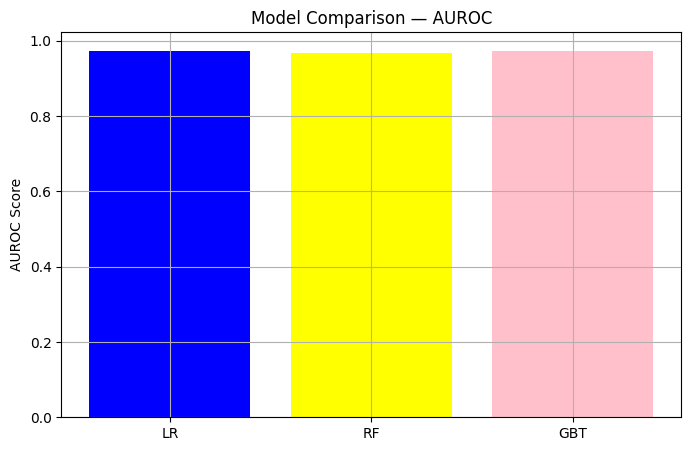

In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

def to_plot_df(pred_df):
    return pred_df.select(
        col("Class").alias("label"),
        vector_to_array("probability")[1].alias("prob")
    ).toPandas()

from sklearn.metrics import precision_recall_curve, roc_curve
import matplotlib.pyplot as plt

def plot_pr_roc(pdf, title):
    y_true = pdf["label"]
    y_prob = pdf["prob"]

  
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(8,5))
    plt.plot(recall, precision, label="PR Curve")
    plt.title(f"Precision-Recall Curve ({title})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.grid(True)
    plt.show()

  
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(8,5))
    plt.plot(fpr, tpr, label="ROC Curve")
    plt.title(f"ROC Curve ({title})")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.grid(True)
    plt.show()

lr_pdf  = to_plot_df(lr_pred)
rf_pdf  = to_plot_df(rf_pred)
gbt_pdf = to_plot_df(gbt_pred)


plot_pr_roc(lr_pdf, "Logistic Regression")


plot_pr_roc(rf_pdf, "Random Forest")


plot_pr_roc(gbt_pdf, "GBT Classifier")

import matplotlib.pyplot as plt

model_names = ["LR", "RF", "GBT"]
auprc_vals = [
    pr_evaluator.evaluate(lr_pred),
    pr_evaluator.evaluate(rf_pred),
    pr_evaluator.evaluate(gbt_pred)
]

auroc_vals = [
    roc_evaluator.evaluate(lr_pred),
    roc_evaluator.evaluate(rf_pred),
    roc_evaluator.evaluate(gbt_pred)
]

plt.figure(figsize=(8,5))
plt.bar(model_names, auprc_vals, color=["blue","yellow","pink"])
plt.title("Model Comparison — AUPRC")
plt.ylabel("AUPRC Score")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(model_names, auroc_vals, color=["blue","yellow","pink"])
plt.title("Model Comparison — AUROC")
plt.ylabel("AUROC Score")
plt.grid(True)
plt.show()

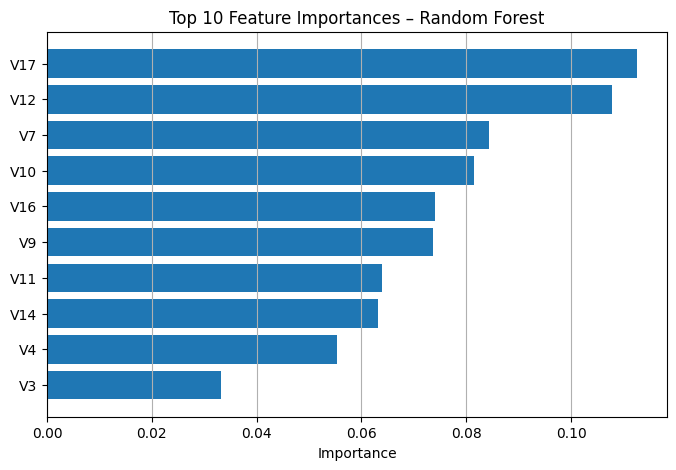

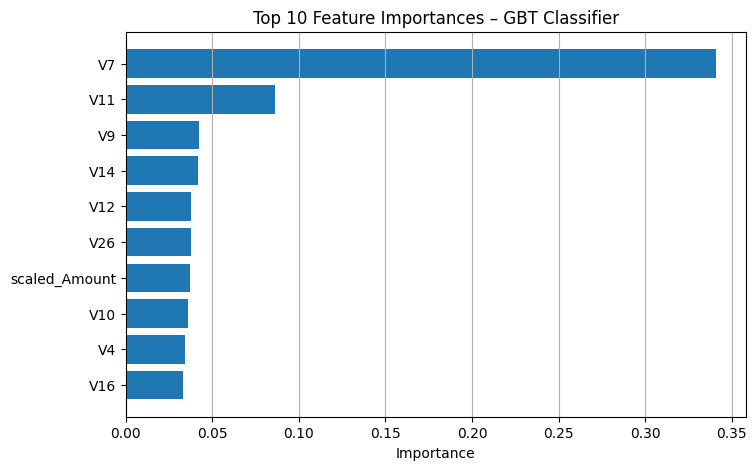

In [0]:
import numpy as np
import matplotlib.pyplot as plt


feature_names = [f"V{i}" for i in range(1, 29)] + ["scaled_Time", "scaled_Amount"]

def plot_feature_importance(model, model_name, top_n=10):
    importances = np.array(model.featureImportances.toArray())
    

    feats = list(zip(feature_names, importances))
    feats_sorted = sorted(feats, key=lambda x: x[1], reverse=True)[:top_n]
    
    names = [f[0] for f in feats_sorted]
    vals  = [f[1] for f in feats_sorted]
    
    plt.figure(figsize=(8,5))
    plt.barh(names[::-1], vals[::-1]) 
    plt.title(f"Top {top_n} Feature Importances – {model_name}")
    plt.xlabel("Importance")
    plt.grid(axis="x")
    plt.show()


plot_feature_importance(rf_model, "Random Forest", top_n=10)


plot_feature_importance(gbt_model, "GBT Classifier", top_n=10)


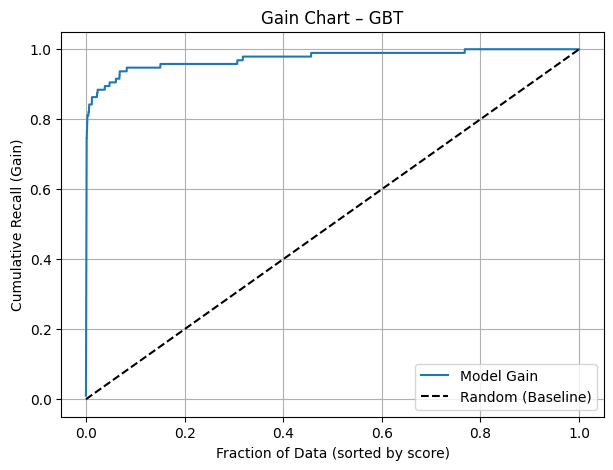

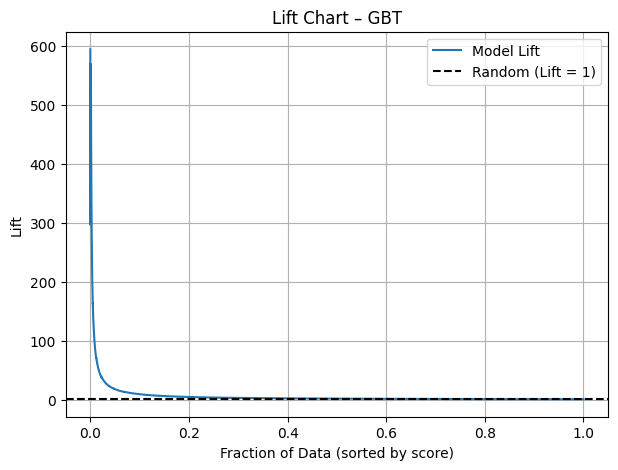

In [0]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col


lift_df = gbt_pred.select(
    col("Class").alias("label"),
    vector_to_array("probability")[1].alias("prob")
).toPandas()

import numpy as np
import matplotlib.pyplot as plt


lift_df_sorted = lift_df.sort_values("prob", ascending=False).reset_index(drop=True)

N = len(lift_df_sorted)
total_positives = lift_df_sorted["label"].sum()


lift_df_sorted["n_obs"] = np.arange(1, N+1)


lift_df_sorted["perc_data"] = lift_df_sorted["n_obs"] / N #x-axis


lift_df_sorted["cum_positives"] = lift_df_sorted["label"].cumsum()
lift_df_sorted["recall"] = lift_df_sorted["cum_positives"] / total_positives  


lift_df_sorted["lift"] = lift_df_sorted["recall"] / lift_df_sorted["perc_data"]

plt.figure(figsize=(7,5))
plt.plot(lift_df_sorted["perc_data"], lift_df_sorted["recall"], label="Model Gain")
plt.plot([0,1], [0,1], 'k--', label="Random (Baseline)")
plt.xlabel("Fraction of Data (sorted by score)")
plt.ylabel("Cumulative Recall (Gain)")
plt.title("Gain Chart – GBT")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(lift_df_sorted["perc_data"], lift_df_sorted["lift"], label="Model Lift")
plt.axhline(1.0, color='k', linestyle='--', label="Random (Lift = 1)")
plt.xlabel("Fraction of Data (sorted by score)")
plt.ylabel("Lift")
plt.title("Lift Chart – GBT")
plt.grid(True)
plt.legend()
plt.show()


--- Logistic Regression ---
Using lr_model to create train predictions.
Using existing test prediction variable: lr_pred
Large DF (227183 rows) — sampling fraction 0.4402 (~100000 rows) for plotting.


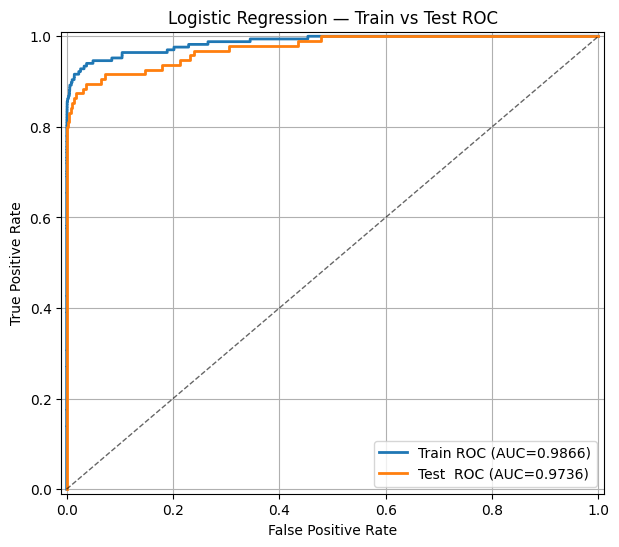


--- Random Forest ---
Using rf_model to create train predictions.
Using existing test prediction variable: rf_pred
Large DF (227183 rows) — sampling fraction 0.4402 (~100000 rows) for plotting.


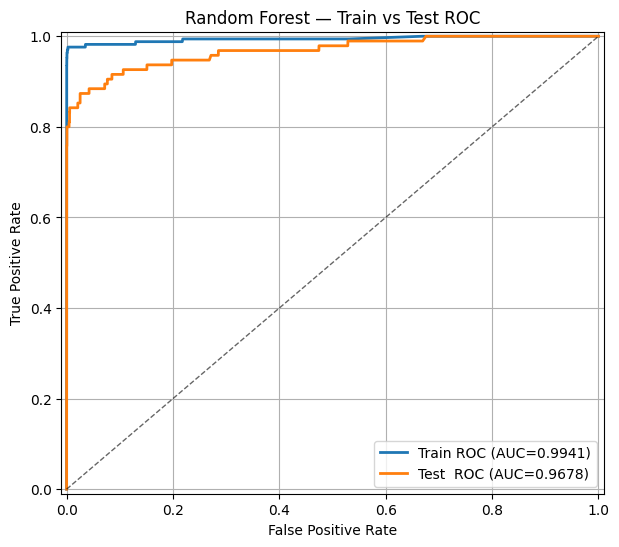


--- GBT Classifier ---
Using gbt_model to create train predictions.
Using existing test prediction variable: gbt_pred
Large DF (227183 rows) — sampling fraction 0.4402 (~100000 rows) for plotting.


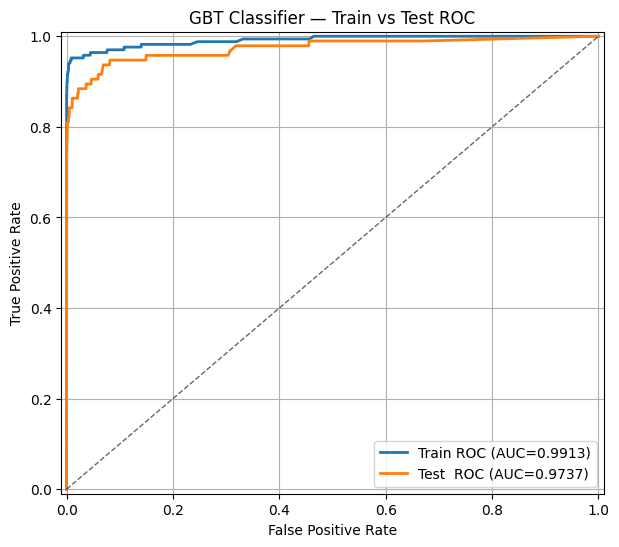

In [0]:

import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array
from sklearn.metrics import roc_curve, auc


MAX_ROWS_FOR_PLOTTING = 100000  

def maybe_sample_for_pandas(spark_df, max_rows=MAX_ROWS_FOR_PLOTTING, seed=42):
    
    try:
        n = spark_df.count()
    except Exception as e:
        print("Warning: couldn't get count:", e)
        # fallback to sampling a small fraction
        return spark_df.sample(False, 0.1, seed=seed)
    if n <= max_rows:
        return spark_df
    frac = float(max_rows) / float(n)
    print(f"Large DF ({n} rows) — sampling fraction {frac:.4f} (~{max_rows} rows) for plotting.")
    return spark_df.sample(False, frac, seed=seed)

def df_to_probs_labels(pred_df):
    """Return (probs, labels) numpy arrays safely for plotting (uses sampling if large)."""
    safe_df = maybe_sample_for_pandas(pred_df)
    pdf = safe_df.select(
        col("Class").alias("label"),
        vector_to_array("probability")[1].alias("prob")
    ).toPandas()
    return pdf["prob"].values, pdf["label"].values

def plot_train_vs_test_roc(train_pred_df, test_pred_df, model_name):
    try:
        train_probs, train_labels = df_to_probs_labels(train_pred_df)
        test_probs, test_labels   = df_to_probs_labels(test_pred_df)
    except Exception as e:
        print(f"Failed to extract probs/labels for {model_name}: {e}")
        return

    try:
        fpr_train, tpr_train, _ = roc_curve(train_labels, train_probs)
        fpr_test,  tpr_test,  _ = roc_curve(test_labels, test_probs)
        auc_train = auc(fpr_train, tpr_train)
        auc_test  = auc(fpr_test,  tpr_test)
    except Exception as e:
        print(f"Failed to compute ROC for {model_name}: {e}")
        return

    plt.figure(figsize=(7,6))
    plt.plot(fpr_train, tpr_train, label=f"Train ROC (AUC={auc_train:.4f})", lw=2)
    plt.plot(fpr_test,  tpr_test,  label=f"Test  ROC (AUC={auc_test:.4f})",  lw=2)
    plt.plot([0,1],[0,1],'k--', lw=1, alpha=0.6)
    plt.xlim([-0.01,1.01])
    plt.ylim([-0.01,1.01])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — Train vs Test ROC")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# For each model: get train & test predictions
models_info = [
    ("Logistic Regression", "lr_model", "lr_pred"),
    ("Random Forest",        "rf_model", "rf_pred"),
    ("GBT Classifier",       "gbt_model","gbt_pred"),
]

for model_name, model_obj_name, test_pred_name in models_info:
    print("\n---", model_name, "---")
    train_pred_df = None
    test_pred_df  = None

    # train predictions
    if model_obj_name in globals():
        try:
            model_obj = globals()[model_obj_name]
            train_pred_df = model_obj.transform(train_df)
            print("Using", model_obj_name, "to create train predictions.")
        except Exception as e:
            print("Could not transform train_df with", model_obj_name, ":", e)

    # fallback
    train_var_name = model_obj_name + "_train_pred"
    if train_pred_df is None and train_var_name in globals():
        train_pred_df = globals()[train_var_name]
        print("Using precomputed", train_var_name)

    # test prediction
    if test_pred_name in globals():
        test_pred_df = globals()[test_pred_name]
        print("Using existing test prediction variable:", test_pred_name)
    else:
        # fallback
        if model_obj_name in globals():
            try:
                test_pred_df = globals()[model_obj_name].transform(test_df)
                print("Created test predictions using", model_obj_name)
            except Exception as e:
                print("Could not create test predictions using", model_obj_name, ":", e)

    # final checks
    if train_pred_df is None:
        print(f"SKIPPING {model_name}: train predictions not available.")
        continue
    if test_pred_df is None:
        print(f"SKIPPING {model_name}: test predictions not available.")
        continue

    # Plot
    plot_train_vs_test_roc(train_pred_df, test_pred_df, model_name)


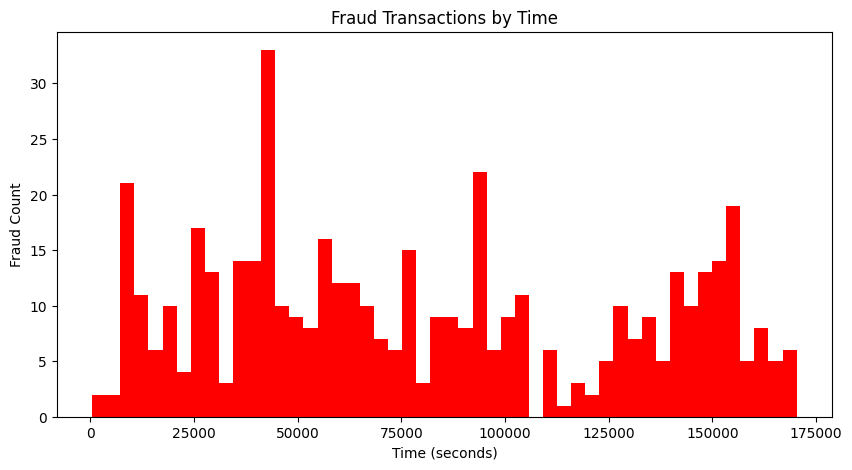

In [0]:
pdf = final_df.select("Time", "Class").toPandas()

plt.figure(figsize=(10,5))
plt.hist(pdf[pdf["Class"]==1]["Time"], bins=50, color='red')
plt.title("Fraud Transactions by Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Fraud Count")
plt.show()


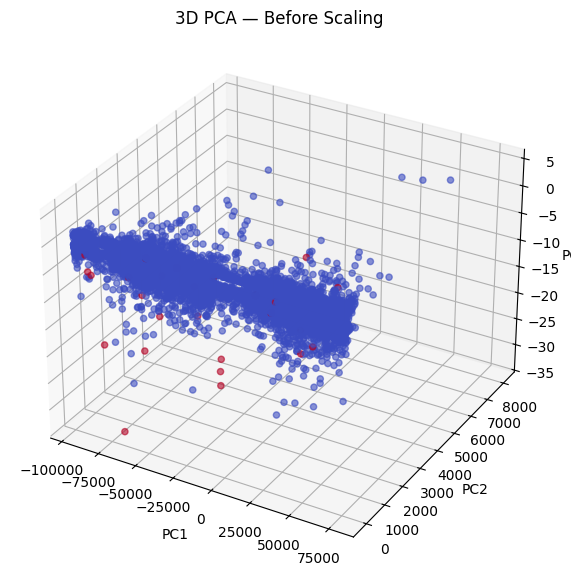

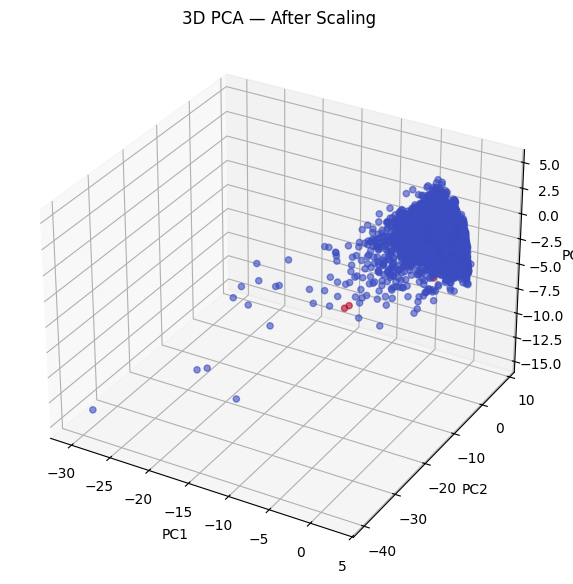

In [0]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# sample dataset for plotting
pdf = df.sample(False, 0.05, seed=42).toPandas()

features = pdf.drop(columns=["Class"])
X = features.values

pca = PCA(n_components=3)
components = pca.fit_transform(X)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(components[:,0], components[:,1], components[:,2],
                     c=pdf["Class"], cmap="coolwarm", alpha=0.6)

ax.set_title("3D PCA — Before Scaling")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

from pyspark.ml.functions import vector_to_array

# Extract scaled features into columns
df_scaled_plot = df_scaled.select(
    "Class",
    *[vector_to_array("scaled_features")[i].alias(f"scaled_{i}") for i in range(2)],  # Time, Amount
    *[f"V{i}" for i in range(1,29)]
)

pdf_scaled = df_scaled_plot.sample(False, 0.05, seed=42).toPandas()

X_scaled = pdf_scaled.drop(columns=["Class"]).values

pca2 = PCA(n_components=3)
components2 = pca2.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(components2[:,0], components2[:,1], components2[:,2],
                     c=pdf_scaled["Class"], cmap="coolwarm", alpha=0.6)

ax.set_title("3D PCA — After Scaling")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()


In [0]:
gold_path = "/Volumes/workspace/default/bigdata/gold_fraud/"

final_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save(gold_path)

print("GOLD table saved!")


GOLD table saved!
